In [1]:
# ==========================
# 1. Setup & auto path correction
# ==========================
import os

# Move up one level if running from notebooks/
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

print("📁 Current working directory:", os.getcwd())

# Create necessary directories
for d in ["data/processed", "models"]:
    os.makedirs(d, exist_ok=True)

# Configuration
RAW_DATA_DIR = "data/raw"          # will find nested s1/... folders automatically
PROCESSED_DIR = "data/processed"
MODEL_DIR = "models"
IMAGE_SIZE = (256, 256)
CLIP_MIN, CLIP_MAX = -50.0, 15.0
DTYPE_ACCUM = float

📁 Current working directory: /Users/vainavilad/flood-mumbai


In [2]:
# ==========================
# 2. Imports & helper functions
# ==========================
import numpy as np, json, rasterio
from rasterio.enums import Resampling
from tqdm import tqdm
import albumentations as A

def load_raster(path):
    try:
        with rasterio.open(path) as src:
            img = src.read(1, out_shape=(src.height, src.width), resampling=Resampling.bilinear)
        return img.astype(np.float32)
    except Exception as e:
        print("⚠️ Error loading:", path, e)
        return None

def get_transform():
    return A.Compose([
        A.Resize(*IMAGE_SIZE),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
    ])

def preprocess_sample(vv_path, vh_path, mask_path, transform, gmean, gstd):
    vv, vh, mask = load_raster(vv_path), load_raster(vh_path), load_raster(mask_path)
    if vv is None or vh is None or mask is None: return None, None
    mask = (mask > 0).astype(np.uint8)
    img = np.stack([vv, vh], -1)
    img = np.clip(img, CLIP_MIN, CLIP_MAX)
    aug = transform(image=img, mask=mask)
    arr = aug["image"].astype(np.float32)
    for c in range(2):
        arr[..., c] = (arr[..., c] - gmean[c]) / (gstd[c] + 1e-8)
    return arr, aug["mask"].astype(np.uint8)

In [3]:
# ==========================
# 3. Process dataset and save mean/std (nested-folder compatible)
# ==========================
def process_dataset():
    transform = get_transform()
    valid_dirs, samples = [], []

    for root, _, files in os.walk(RAW_DATA_DIR):
        if all(name in files for name in ["VV.tif", "VH.tif", "LabelWater.tif"]):
            vv, vh = load_raster(os.path.join(root, "VV.tif")), load_raster(os.path.join(root, "VH.tif"))
            if vv is not None and vh is not None:
                img = np.stack([vv, vh], -1)
                img = np.clip(img, CLIP_MIN, CLIP_MAX)
                aug = transform(image=img)["image"].astype(np.float32)
                samples.append(aug)
                valid_dirs.append(root)

    if not samples:
        raise RuntimeError(f"No valid samples found under {RAW_DATA_DIR}. "
                           "Ensure .tif files are inside nested s1/... folders.")

    vv_all = np.concatenate([s[...,0].astype(DTYPE_ACCUM).ravel() for s in samples])
    vh_all = np.concatenate([s[...,1].astype(DTYPE_ACCUM).ravel() for s in samples])
    gmean = [float(np.mean(vv_all)), float(np.mean(vh_all))]
    gstd = [float(np.std(vv_all)), float(np.std(vh_all))]
    print("📊 Global mean/std:", gmean, gstd)

    X, y = [], []
    for root in tqdm(valid_dirs, desc="Processing"):
        vv, vh, mask = [os.path.join(root, f) for f in ("VV.tif", "VH.tif", "LabelWater.tif")]
        img, msk = preprocess_sample(vv, vh, mask, transform, gmean, gstd)
        if img is not None and msk is not None:
            X.append(img)
            y.append(msk)

    X, y = np.asarray(X, np.float32), np.asarray(y, np.uint8)
    np.save(os.path.join(PROCESSED_DIR, "images.npy"), X)
    np.save(os.path.join(PROCESSED_DIR, "masks.npy"), y)
    with open(os.path.join(MODEL_DIR, "global_stats.json"), "w") as f:
        json.dump({"mean": gmean, "std": gstd}, f, indent=2)
    print("✅ Saved processed data & global_stats.json")
    return X, y

X, y = process_dataset()

📊 Global mean/std: [-11.281756708657582, -18.101943310824943] [4.945670508896773, 5.675061883943235]


Processing: 100%|███████████████████████████████████| 900/900 [00:09<00:00, 99.17it/s]


✅ Saved processed data & global_stats.json


Images: (900, 256, 256, 2) Masks: (900, 256, 256) Mask values: [0 1]


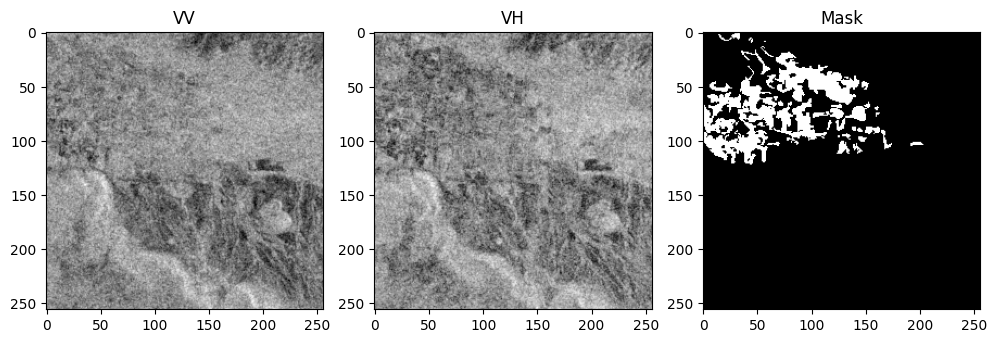

In [4]:
# ==========================
# 4. Quick visual check
# ==========================
import matplotlib.pyplot as plt
print("Images:", X.shape, "Masks:", y.shape, "Mask values:", np.unique(y))
i = 0
plt.figure(figsize=(10,4))
plt.subplot(1,3,1); plt.imshow(X[i,:,:,0], cmap='gray'); plt.title("VV")
plt.subplot(1,3,2); plt.imshow(X[i,:,:,1], cmap='gray'); plt.title("VH")
plt.subplot(1,3,3); plt.imshow(y[i], cmap='gray'); plt.title("Mask")
plt.tight_layout(); plt.show()

In [5]:
# ==========================
# 5. Define U-Net
# ==========================
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Concatenate, BatchNormalization, Activation
import tensorflow as tf

def dice_coefficient(y_true, y_pred):
    y_true_f, y_pred_f = tf.reshape(y_true, [-1]), tf.reshape(y_pred, [-1])
    inter = tf.reduce_sum(y_true_f * y_pred_f)
    return (2.*inter + 1.) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + 1.)

def iou_metric(y_true, y_pred):
    y_true_f, y_pred_f = tf.reshape(y_true, [-1]), tf.round(tf.reshape(y_pred, [-1]))
    inter = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - inter
    return inter / (union + 1e-7)

def build_unet():
    inp = Input((256,256,2))
    # Encoder
    c1 = Conv2D(64,3,padding='same')(inp); c1 = BatchNormalization()(c1); c1 = Activation('relu')(c1)
    c1 = Conv2D(64,3,padding='same')(c1); c1 = BatchNormalization()(c1); c1 = Activation('relu')(c1)
    p1 = MaxPooling2D()(c1)
    c2 = Conv2D(128,3,padding='same')(p1); c2 = BatchNormalization()(c2); c2 = Activation('relu')(c2)
    c2 = Conv2D(128,3,padding='same')(c2); c2 = BatchNormalization()(c2); c2 = Activation('relu')(c2)
    p2 = MaxPooling2D()(c2)
    # Bottleneck
    c3 = Conv2D(256,3,padding='same')(p2); c3 = BatchNormalization()(c3); c3 = Activation('relu')(c3)
    c3 = Conv2D(256,3,padding='same')(c3); c3 = BatchNormalization()(c3); c3 = Activation('relu')(c3)
    # Decoder
    u1 = UpSampling2D()(c3); m1 = Concatenate()([u1,c2])
    c4 = Conv2D(128,3,padding='same')(m1); c4 = BatchNormalization()(c4); c4 = Activation('relu')(c4)
    c4 = Conv2D(128,3,padding='same')(c4); c4 = BatchNormalization()(c4); c4 = Activation('relu')(c4)
    u2 = UpSampling2D()(c4); m2 = Concatenate()([u2,c1])
    c5 = Conv2D(64,3,padding='same')(m2); c5 = BatchNormalization()(c5); c5 = Activation('relu')(c5)
    c5 = Conv2D(64,3,padding='same')(c5); c5 = BatchNormalization()(c5); c5 = Activation('relu')(c5)
    out = Conv2D(1,1,activation='sigmoid')(c5)
    model = Model(inp, out)
    model.compile(optimizer='adam', loss='binary_crossentropy',
                  metrics=['accuracy', dice_coefficient, iou_metric])
    return model

model = build_unet()
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 256, 256, 2)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 256, 256, 64)         1216      ['input_1[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 256, 256, 64)         256       ['conv2d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 activation (Activation)     (None, 256, 256, 64)         0         ['batch_normalization[0][0

Epoch 1/20
180/180 [==============================] - 586s 3s/step - loss: 0.3158 - accuracy: 0.8922 - dice_coefficient: 0.3841 - iou_metric: 0.3850 - val_loss: 0.6376 - val_accuracy: 0.8335 - val_dice_coefficient: 0.2136 - val_iou_metric: 0.0099 - lr: 0.0010
Epoch 2/20
180/180 [==============================] - 671s 4s/step - loss: 0.2058 - accuracy: 0.9246 - dice_coefficient: 0.4624 - iou_metric: 0.4568 - val_loss: 0.2530 - val_accuracy: 0.8579 - val_dice_coefficient: 0.3582 - val_iou_metric: 0.1519 - lr: 0.0010
Epoch 3/20
180/180 [==============================] - 636s 4s/step - loss: 0.1934 - accuracy: 0.9287 - dice_coefficient: 0.4712 - iou_metric: 0.4593 - val_loss: 0.1991 - val_accuracy: 0.9148 - val_dice_coefficient: 0.4400 - val_iou_metric: 0.3570 - lr: 0.0010
Epoch 4/20
180/180 [==============================] - 588s 3s/step - loss: 0.2079 - accuracy: 0.9212 - dice_coefficient: 0.4367 - iou_metric: 0.4012 - val_loss: 0.1597 - val_accuracy: 0.9464 - val_dice_coefficient: 0.570

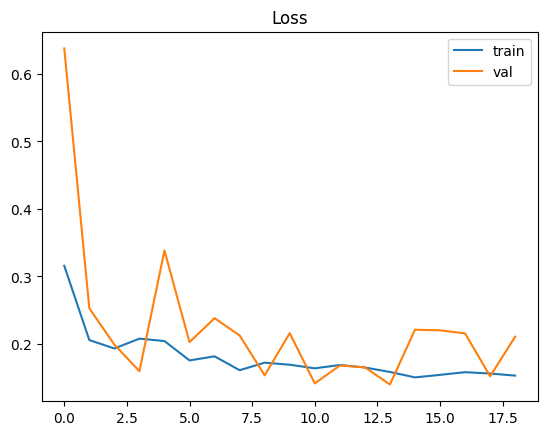

In [6]:
# ==========================
# 6. Train model
# ==========================
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np

y = np.expand_dims(y, -1).astype(np.float32)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

history = model.fit(
    X_train, y_train,
    batch_size=4, epochs=20,
    validation_data=(X_val, y_val),
    callbacks=callbacks, verbose=1
)

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend(); plt.title('Loss'); plt.show()

In [7]:
# ==========================
# 7. Evaluate & save
# ==========================
import numpy as np, os

val_pred = (model.predict(X_val) > 0.5).astype(np.uint8)
dice_scores = [2*np.sum(y_val[i]*val_pred[i]) / (np.sum(y_val[i]) + np.sum(val_pred[i]) + 1e-7) for i in range(len(y_val))]
print("Mean Validation Dice:", np.mean(dice_scores))

model.save(os.path.join(MODEL_DIR, "unet_flood.keras"))
model.save(os.path.join(MODEL_DIR, "unet_flood.h5"))
model.save(os.path.join(MODEL_DIR, "unet_flood_savedmodel"))
print("✅ Models saved in:", MODEL_DIR)

6/6 [==============================] - 23s 4s/step
Mean Validation Dice: 0.4725069288546527


/Users/vainavilad/flood-mumbai/venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


INFO:tensorflow:Assets written to: models/unet_flood_savedmodel/assets


INFO:tensorflow:Assets written to: models/unet_flood_savedmodel/assets


✅ Models saved in: models
